ЗАВДАННЯ 1
N = 1000
Оцінка інтеграла методом Монте-Карло: 0.985765

ЗАВДАННЯ 2
Точне значення: 1.000000
Оцінка Монте-Карло: 0.985765
Абсолютна похибка: 0.014235
Відносна похибка: 1.4235%

Похибка при N = 1000 є невеликою відносно точного значення.
Це узгоджується з тим, що 1000 випробувань є вже достатньою,
але все ще відносно невеликою кількістю для методу Монте-Карло.


ЗАВДАННЯ 3
     N   оцінка  абсолютна_похибка
   100 0.978231           0.021769
  1000 0.985765           0.014235
 10000 0.999494           0.000506
100000 0.999605           0.000395

Похибка при N=100: 0.021769
Похибка при N=10000: 0.000506
Відношення похибок: 43.05

При збільшенні N від 100 до 10000 кількість випробувань
зросла у 100 разів. Теоретично стандартна похибка зменшується
пропорційно 1/sqrt(N), тому очікується приблизно 10-кратне
зменшення похибки, а не 100-кратне.

Через випадковий характер методу фактичне відношення може
відрізнятися від 10.



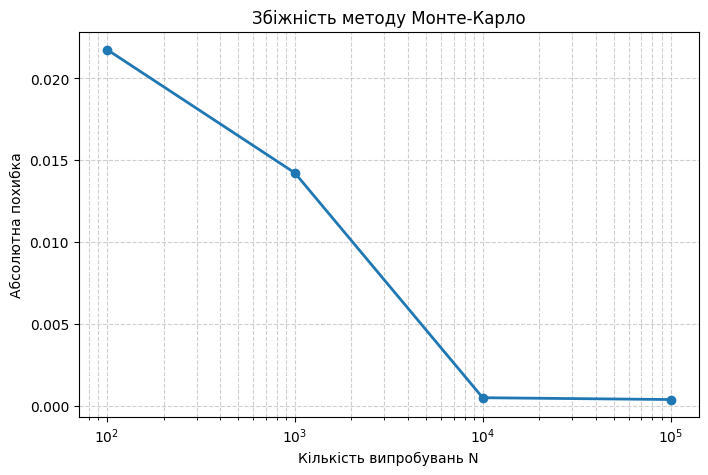


На графіку видно загальну тенденцію до зменшення абсолютної
похибки зі збільшенням N. Спадання не є строго монотонним,
оскільки кожна оцінка залежить від випадкової вибірки.

Загальна форма відповідає очікуваній залежності приблизно
1/sqrt(N).


ЗАВДАННЯ 5

Оцінка інтеграла методом Монте-Карло є вибірковим середнім
значень cos(x), помноженим на довжину інтервалу.

Закон великих чисел гарантує, що при збільшенні кількості
незалежних випробувань вибіркове середнє наближається до
математичного сподівання, а тому оцінка інтеграла наближається
до точного значення.

Центральна гранична теорема пояснює розподіл і масштаб
випадкової похибки оцінки при великому N.

Стандартна похибка має порядок:

        σ / sqrt(N)

Тому якщо кількість випробувань збільшити у 100 разів,
sqrt(100) = 10, і типова похибка зменшується приблизно
у 10 разів.

Якщо збільшити кількість випробувань у 4 рази, похибка
зменшується приблизно у 2 рази, а не у 4 рази.


ПІДСУМОК
Варіант: 4
Місто: Харків
Тип задачі: визначе

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ВАРІАНТ 4 — ХАРКІВ
# Інтеграл: ∫₀^(π/2) cos(x) dx
# Точне значення = 1
# ============================================================

exact = 1.0
a = 0
b = np.pi / 2


# ============================================================
# ЗАВДАННЯ 1. Оцінка методом Монте-Карло
# ============================================================

N = 1000

np.random.seed(4)

x = np.random.uniform(a, b, N)
y = np.cos(x)

mc_estimate = (b - a) * np.mean(y)

print("ЗАВДАННЯ 1")
print(f"N = {N}")
print(f"Оцінка інтеграла методом Монте-Карло: {mc_estimate:.6f}")


# ============================================================
# ЗАВДАННЯ 2. Порівняння з точним значенням
# ============================================================

absolute_error = abs(mc_estimate - exact)
relative_error = absolute_error / exact * 100

print("\nЗАВДАННЯ 2")
print(f"Точне значення: {exact:.6f}")
print(f"Оцінка Монте-Карло: {mc_estimate:.6f}")
print(f"Абсолютна похибка: {absolute_error:.6f}")
print(f"Відносна похибка: {relative_error:.4f}%")

print("""
Похибка при N = 1000 є невеликою відносно точного значення.
Це узгоджується з тим, що 1000 випробувань є вже достатньою,
але все ще відносно невеликою кількістю для методу Монте-Карло.
""")


# ============================================================
# ЗАВДАННЯ 3. Збіжність за кількістю випробувань
# ============================================================

N_values = [100, 1000, 10000, 100000]

results = []

for N in N_values:
    np.random.seed(4)

    x = np.random.uniform(a, b, N)
    estimate = (b - a) * np.mean(np.cos(x))
    error = abs(estimate - exact)

    results.append([N, estimate, error])

results_df = pd.DataFrame(
    results,
    columns=["N", "оцінка", "абсолютна_похибка"]
)

print("\nЗАВДАННЯ 3")
print(results_df.to_string(index=False))

error_100 = results_df.loc[
    results_df["N"] == 100, "абсолютна_похибка"
].iloc[0]

error_10000 = results_df.loc[
    results_df["N"] == 10000, "абсолютна_похибка"
].iloc[0]

print(
    f"\nПохибка при N=100: {error_100:.6f}"
)

print(
    f"Похибка при N=10000: {error_10000:.6f}"
)

print(
    f"Відношення похибок: {error_100 / error_10000:.2f}"
)

print("""
При збільшенні N від 100 до 10000 кількість випробувань
зросла у 100 разів. Теоретично стандартна похибка зменшується
пропорційно 1/sqrt(N), тому очікується приблизно 10-кратне
зменшення похибки, а не 100-кратне.

Через випадковий характер методу фактичне відношення може
відрізнятися від 10.
""")


# ============================================================
# ЗАВДАННЯ 4. Графік похибки залежно від N
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["N"],
    results_df["абсолютна_похибка"],
    marker="o",
    linewidth=2
)

plt.xscale("log")
plt.xlabel("Кількість випробувань N")
plt.ylabel("Абсолютна похибка")
plt.title("Збіжність методу Монте-Карло")
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.show()

print("""
На графіку видно загальну тенденцію до зменшення абсолютної
похибки зі збільшенням N. Спадання не є строго монотонним,
оскільки кожна оцінка залежить від випадкової вибірки.

Загальна форма відповідає очікуваній залежності приблизно
1/sqrt(N).
""")


# ============================================================
# ЗАВДАННЯ 5. Закон великих чисел і ЦГТ
# ============================================================

print("""
ЗАВДАННЯ 5

Оцінка інтеграла методом Монте-Карло є вибірковим середнім
значень cos(x), помноженим на довжину інтервалу.

Закон великих чисел гарантує, що при збільшенні кількості
незалежних випробувань вибіркове середнє наближається до
математичного сподівання, а тому оцінка інтеграла наближається
до точного значення.

Центральна гранична теорема пояснює розподіл і масштаб
випадкової похибки оцінки при великому N.

Стандартна похибка має порядок:

        σ / sqrt(N)

Тому якщо кількість випробувань збільшити у 100 разів,
sqrt(100) = 10, і типова похибка зменшується приблизно
у 10 разів.

Якщо збільшити кількість випробувань у 4 рази, похибка
зменшується приблизно у 2 рази, а не у 4 рази.
""")


# ============================================================
# ПІДСУМОК
# ============================================================

print("\n" + "=" * 60)
print("ПІДСУМОК")
print("=" * 60)

print("Варіант: 4")
print("Місто: Харків")
print("Тип задачі: визначений інтеграл")
print("Інтеграл: ∫₀^(π/2) cos(x) dx")
print(f"Точне значення: {exact}")
print(f"Оцінка при N=1000: {mc_estimate:.6f}")
print(f"Абсолютна похибка: {absolute_error:.6f}")


In [3]:
# ============================================================
# КОНТРОЛЬНІ ПИТАННЯ
# ============================================================

# ------------------------------------------------------------
# 1. Чому оцінка методом Монте-Карло — це вибіркове середнє?
# ------------------------------------------------------------

print("""
1. Чому оцінка методом Монте-Карло — це вибіркове середнє?

Для варіанта 4 випадково генеруються значення x на відрізку
[0, π/2], після чого для кожного значення обчислюється cos(x).

Середнє значення cos(x) за всіма N випробуваннями є вибірковим
середнім. Воно оцінює математичне сподівання cos(X).

Для знаходження інтеграла це середнє множиться на довжину
відрізка π/2.

Закон великих чисел гарантує, що зі збільшенням N ця оцінка
наближається до точного значення інтеграла.
""")


# ------------------------------------------------------------
# 2. Чому вчетверо більше випробувань дає вдвічі меншу похибку?
# ------------------------------------------------------------

print("""
2. Чому вчетверо більше випробувань дає лише вдвічі меншу похибку?

Стандартна похибка вибіркового середнього має вигляд:

σ / sqrt(N)

Якщо кількість випробувань збільшити у 4 рази, то:

sqrt(4N) = 2 * sqrt(N)

Отже, стандартна похибка зменшується приблизно у 2 рази,
а не у 4 рази.

Саме корінь квадратний із N визначає швидкість збіжності
методу Монте-Карло.
""")


# ------------------------------------------------------------
# 3. Чому середнє потрібно множити на довжину відрізка?
# ------------------------------------------------------------

print("""
3. Чому середнє cos(x) потрібно множити саме на π/2?

Для рівномірно розподіленої випадкової величини X на [a, b]:

E[f(X)] = 1/(b-a) * ∫(a до b) f(x) dx

Тому:

∫(a до b) f(x) dx = (b-a) * E[f(X)]

У моєму варіанті:

a = 0
b = π/2
f(x) = cos(x)

Тому оцінка інтеграла обчислюється так:

π/2 * mean(cos(x))

Якщо залишити лише mean(cos(x)), це буде оцінка
математичного сподівання, а не самого інтеграла.
""")


# ------------------------------------------------------------
# 4. Зв'язок із законом великих чисел
# ------------------------------------------------------------

print("""
4. Який результат теорії гарантує збіжність?

Закон великих чисел гарантує, що вибіркове середнє
незалежних випадкових величин при збільшенні кількості
випробувань наближається до їх математичного сподівання.

Тому оцінка Монте-Карло при збільшенні N наближається
до точного значення інтеграла.

Центральна гранична теорема додатково описує поведінку
випадкової похибки оцінки при великому N.
""")


# ------------------------------------------------------------
# 5. Чому похибка має порядок 1/sqrt(N)?
# ------------------------------------------------------------

print("""
5. Чому похибка убуває як 1/sqrt(N)?

Оцінка Монте-Карло є вибірковим середнім.

Для вибіркового середнього стандартна похибка має порядок:

σ / sqrt(N)

Тому при збільшенні N у 100 разів типова похибка
зменшується приблизно у sqrt(100) = 10 разів.

Отже, збіжність Монте-Карло має порядок 1/sqrt(N),
а не 1/N.
""")


# ============================================================
# ПІДСУМКОВА ВІДПОВІДЬ НА КОНТРОЛЬНІ ПИТАННЯ
# ============================================================

print("""
============================================================
ПІДСУМОК КОНТРОЛЬНИХ ПИТАНЬ
============================================================

Для варіанта 4 метод Монте-Карло оцінює інтеграл

∫₀^(π/2) cos(x) dx = 1.

Оцінка є вибірковим середнім значень cos(x), помноженим
на довжину інтервалу π/2.

Закон великих чисел пояснює наближення оцінки до точного
значення при збільшенні кількості випробувань.

Стандартна похибка має порядок 1/sqrt(N), тому збільшення
N у 4 рази дає приблизно вдвічі меншу похибку, а збільшення
N у 100 разів — приблизно у 10 разів меншу похибку.

Випадковість симуляції означає, що фактична похибка при
окремих N може коливатися, але загальна тенденція при
збільшенні N відповідає залежності 1/sqrt(N).
""")



1. Чому оцінка методом Монте-Карло — це вибіркове середнє?

Для варіанта 4 випадково генеруються значення x на відрізку
[0, π/2], після чого для кожного значення обчислюється cos(x).

Середнє значення cos(x) за всіма N випробуваннями є вибірковим
середнім. Воно оцінює математичне сподівання cos(X).

Для знаходження інтеграла це середнє множиться на довжину
відрізка π/2.

Закон великих чисел гарантує, що зі збільшенням N ця оцінка
наближається до точного значення інтеграла.


2. Чому вчетверо більше випробувань дає лише вдвічі меншу похибку?

Стандартна похибка вибіркового середнього має вигляд:

σ / sqrt(N)

Якщо кількість випробувань збільшити у 4 рази, то:

sqrt(4N) = 2 * sqrt(N)

Отже, стандартна похибка зменшується приблизно у 2 рази,
а не у 4 рази.

Саме корінь квадратний із N визначає швидкість збіжності
методу Монте-Карло.


3. Чому середнє cos(x) потрібно множити саме на π/2?

Для рівномірно розподіленої випадкової величини X на [a, b]:

E[f(X)] = 1/(b-a) * ∫(a до b) f(x) dx

